# WES 267 Final Project 
Minimal executable code without test.

## Goal
Develop a multithreaded real-time server side video application for face and eye detection using [2] Haar cascade classifiers (machine learning-based method for object detection).

## Components used:
- HW-479 - RGB LED module (x1)
- HW-483 - Push Button module (x1)
- AXI GPIO on-board leds (x4)
- AXI GPIO on-board push buttons (x4)
- USB 720p web cam

## Application initialization workflow :
1. Load FPGA bitstream (base.bit)
2. Use %%microblaze base.PMODB to compile and run the C code in the cell on the MicroBlaze processor connected to PMODB.
3. Turn on PMODB LED white indicating application is on but isn't fully ready.
    - White indicates program is loading but is not ready.
    - Blue indicates program is ready all peripherals and web server are active.
    - Green indicates program is actively applying face detection filter.
    - Red indicates program is not applying the filter.
4. Initialize on-board leds on seperate threads. (4)
    - Off indicates filter is off and duty cycle is 0%.
    - Blinking indicates actively trying to detect face and eyes. Frequency is 5Hz with duty cycle 50%.
    - On indicates filter is on and led duty cycle is 100%.
    - Led 0 indicates filter status.
    - Led 1 indicates left eye detection.
    - Led 2 indicates face detection.
    - Led 3 indicates right eye detection.
5. Initialize on-board buttons to toggle filter state. (1)
    - Any button pressed toggles applying the filter. Default is off.
6. Starts Flask Web Server
    - Displays live video stream with video stats.
7. Initialize PMODA push button module to act as a kill switch to stop all threads and shutdown server. (1)
    - Once pressed terminates all threads.
    
## Image Processing
Implemented using locks and seperate threads.
1. Read frame from camera
2. Detect draw boundary boxes
3. Encode to .jpg
4. Send bytes to frames() which is the live video stream for the index.html
OpenCV uses linux V4L2 ARM CPU (PS)   
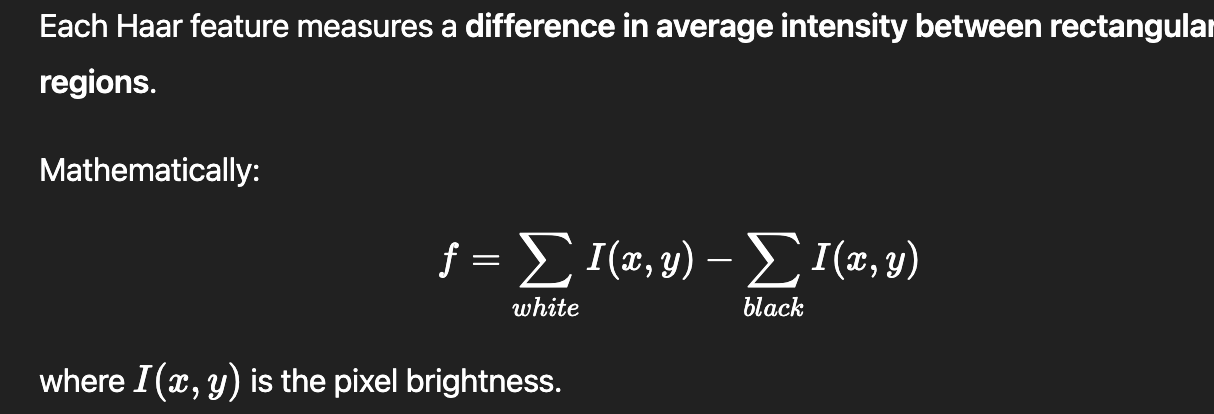

## GitHub Repo
https://github.com/Math140Instructor/wes237a/tree/main/FinalProject

## Video Demo
https://drive.google.com/file/d/1WGeIKf_5KR10oav1O_BOLoHbleNHzj98/view?usp=drive_link

## References
- [1] Pallets, "Serving WSGI Applications," Werkzeug Documentation. [Online]. Available: https://werkzeug.palletsprojects.com/en/stable/serving/
- [2] A. Vidhya, "What is Haar Features Used in Face Detection," Medium, Analytics Vidhya. [Online]. Available: https://medium.com/analytics-vidhya/what-is-haar-features-used-in-face-detection-a7e531c8332b
- [3] A. Vidhya, "Haar Cascades Explained," Medium, Analytics Vidhya. [Online]. Available: https://medium.com/analytics-vidhya/haar-cascades-explained-38210e57970d
- [4] OpenCV, "Face Detection using Haar Cascades (JavaScript Tutorial)," OpenCV Documentation. [Online]. Available: https://docs.opencv.org/4.x/d2/d99/tutorial_js_face_detection.html
- [5] OpenCV, "Cascade Classifier," OpenCV Documentation. [Online]. Available: https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html


In [1]:
import threading
import time

from pynq.overlays.base import BaseOverlay
from pynq.lib.pmod import Pmod_IO

base = BaseOverlay("base.bit")
btns = base.btns_gpio # toggle filter
leds = base.leds # show filter state, face, left eye, and right eye detection state

In [2]:
%%microblaze base.PMODB
#include "gpio.h"
#include "timer.h"
//const int BLUE = 1, GREEN = 2, RED = 4;
gpio ledPins;

int init(){
    gpio parent = gpio_open_device(0);
    ledPins = gpio_configure(parent, 1, 3, 1);
    gpio_set_direction(ledPins, GPIO_OUT);
    return 0;
}

unsigned int write(unsigned int signal){
    if(!ledPins) init();
    gpio_write(ledPins, signal);
    return signal;
}

int pwm(unsigned int freq, unsigned int duty, unsigned int val){
    if(!ledPins) init();
    
    freq = freq==0 ? 1:freq;
    duty = duty%101;
    
    unsigned int us = 1000000; // work in micro secs (us)
    unsigned int T =  (us / freq);

    unsigned int on_us  = T * duty / 100; // convert duty into percent
    unsigned int off_us = T - on_us;

    gpio_write(ledPins, val);
    delay_us(on_us); 
    gpio_write(ledPins, 0);
    delay_us(off_us);

    return 0;
}

unsigned int read(){
    if(!ledPins)init();
    return gpio_read(ledPins);
}

## Multithreaded application using thread safe locking mechanisms

In [ ]:
# show led to be white indicating program is alive but not fully active (WHITE)
write(7)

def blinkOnBoardLed(hz=1,duty=50,ledPos=1):
    hz = 1 if hz==0 else hz
    duty = abs(duty) % 101
    
    if duty==0:
        leds.write(0,ledPos)
        return
    
    #mask=0b1111 #effects all
    pos=2**ledPos
    T = 1./hz
    Ton = T * (duty/100.)
    Toff = T - Ton
    leds.write(pos, pos)
    time.sleep(Ton)
    leds.write(0,pos)
    time.sleep(Toff)
def blink(hz=1,duty=50,ledPos=0,ledBlinkEvent=None, debug=False):
    if debug: 
        print("freq: {}, duty: {}, pos: {}".format(hz,duty,ledPos))
    print("On-board led {} started.".format(ledPos))
    global ledOnBoardMetaData
    while ledBlinkEvent.is_set():
        duty=ledOnBoardMetaData[ledPos]["duty"]
        blinkOnBoardLed(hz,duty,ledPos)
    print("On-board led {} done.".format(ledPos))
    
def startOnBoardLeds(debug=False):
    '''
    4 leds
    led0 = filter state
    led1 = left eye
    led2 = face
    led3 = right eye
    '''
    global ledBlinkEvents    
    ledBlinkEvents = []
    global ledOnBoardMetaData
    ledOnBoardMetaData={}
    for i in range(4):
        hz = i+1 if debug else 5
        duty= 50 # default filter is off need to flash to show they are on
        ledOnBoardMetaData[i]={"hz":hz,"duty":duty}
        ledBlinkEvents.append(threading.Event())
        ledBlinkEvents[i].set()
        threading.Thread(
            target=blink,
            kwargs={
                "hz": hz, # default thinking is blinking
                "duty": duty,
                "ledPos": i,
                "ledBlinkEvent": ledBlinkEvents[i],
                "debug":debug
                },
        ).start()
def turnOnOnBoardLeds():
    global ledOnBoardMetaData
    for i in range(4):
        hz = 5
        duty= 50
        ledOnBoardMetaData[i]["hz"]=hz
        ledOnBoardMetaData[i]["duty"]=duty
def turnOffOnBoardLeds():
    global ledOnBoardMetaData
    for i in range(4):
        duty=0
        ledOnBoardMetaData[i]["duty"]=duty
def terminateOnBoardLeds():
    global ledBlinkEvents
    for i in range(4):
        ledBlinkEvents[i].clear()

# global pmodLedMetaData
# pmodLedMetaData = {"Event": threading.Event(), "hz":50,"duty":100,"val":2}
# pmodLedMetaData["Event"].set()
# def pmodBlink():
#     print("PMOD led on.")
#     write(val)
#     global pmodLedMetaData
#     while pmodLedMetaData["Event"].is_set():
#         hz=pmodLedMetaData["hz"]
#         duty=pmodLedMetaData["duty"]
#         val=pmodLedMetaData["val"]
#         pwm(hz,duty,val)
#     print("PMOD led done.")
#     write(0)
def startPmodLed():
    #
    write(1)
    #threading.Thread(target=pmodBlink).start()
def terminatePmodLed():
    write(0)
    #global pmodLedMetaData
    #pmodLedMetaData["Event"].clear()

# PMODA
# Button Kill Switch 
'''
Master kill switch.
- Will turn off on-board led threads (x4)
- Will turn off PMODB LED thread (x1)
- Will turn off PMODA Button thread (x1)
- Will turn off on-board button thread (x1)
- Will turn off web server thread (x1)
'''
def buttonPMODA():
    global server
    # PMODA, D2 (pin 3)
    button = Pmod_IO(base.PMODA, 2, 'in')
    print("Watching PMODA button on pin 3 (D2)...")
    while True:
        val = button.read()
        if val == 0:
            print("Kill Switch Pressed")
            stopServer()
            break
        time.sleep(0.01)
    print("PMODA  button done.")
def startPmodAButton():
    threading.Thread(target=buttonPMODA).start()
def onBoardButtonListener():
    print("On-board button listener on.")
    global filterStatusEvent, btns, ledOnBoardMetaData
    global closeEvent
    '''
    toggle haar filter
    default is on
    '''
    while not closeEvent.is_set():
        time.sleep(.1)
        if btns.read():
            if filterStatusEvent.is_set():
                filterStatusEvent.clear()
                ledOnBoardMetaData[0]["duty"]=0
                ledOnBoardMetaData[0]["hz"]=5
                write(4)
            else:
                filterStatusEvent.set()
                ledOnBoardMetaData[0]["duty"]=100
                ledOnBoardMetaData[0]["hz"]=5
                write(2)
    print("On-board button listener done.")
def startOnBoardButtonListener():
    threading.Thread(target=onBoardButtonListener).start()

'''
Flask Web Server - serves live video stream with video stats. (BACKEND)
'''
from flask import Flask, Response, render_template
from werkzeug.serving import make_server
import cv2
import threading
import time

app = Flask(__name__)

closeEvent = threading.Event()
blinkEvent = threading.Event()
filterFaceDetectEvent = threading.Event()
filterRightEyeEvent=threading.Event()
filterLeftEyeEvent=threading.Event()
filterStatusEvent = threading.Event()

server = None
server_thread = None
capture_thread = None
detect_thread = None
encode_thread = None

lastFace = None
lastEyes = []
frameCounter = 0

latestRawFrame = None
latestProcessedFrame = None
latestJpeg = None

rawLock = threading.Lock()
processedLock = threading.Lock()
jpegLock = threading.Lock()

face_cascade = cv2.CascadeClassifier(
    "/usr/share/opencv4/haarcascades/haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    "/usr/share/opencv4/haarcascades/haarcascade_eye.xml"
)

if face_cascade.empty():
    raise RuntimeError("Failed to load face cascade")

if eye_cascade.empty():
    raise RuntimeError("Failed to load eye cascade")
def getFCC(fourcc):
    return chr(fourcc & 0xFF) + chr((fourcc >> 8) & 0xFF) +chr((fourcc >> 16) & 0xFF)+chr((fourcc >> 24) & 0xFF)

mode = "Haar Face and Eye Detection"
detectEveryN = 15
detectScale = 0.50
fps_value = 30

camera = cv2.VideoCapture(0, cv2.CAP_V4L2)
camera.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc('Y', 'U', 'Y', 'V')) #('M','J','P','G')) #
camera.set(cv2.CAP_PROP_FRAME_WIDTH, 320) 
camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)
camera.set(cv2.CAP_PROP_FPS, fps_value)
camera.set(cv2.CAP_PROP_BUFFERSIZE, 1)

if not camera.isOpened():
    raise RuntimeError("Failed to open camera")

print("Actual width:", camera.get(cv2.CAP_PROP_FRAME_WIDTH))
print("Actual height:", camera.get(cv2.CAP_PROP_FRAME_HEIGHT))
print("Actual fps:", camera.get(cv2.CAP_PROP_FPS))
print("Actual fourcc:", getFCC(int(camera.get(cv2.CAP_PROP_FOURCC))))


def captureLoop():
    global latestRawFrame
    print("Capture loop active.")
    while not closeEvent.is_set():
        success, frame = camera.read()
        if not success or frame is None:
            time.sleep(0.005)
            continue

        with rawLock:
            latestRawFrame = frame.copy()

    print("Capture loop done.")

def detectLoop():
    global latestRawFrame, latestProcessedFrame
    global frameCounter, lastFace, lastEyes
    print("Detect loop active.")
    while not closeEvent.is_set():
        with rawLock:
            frame = None if latestRawFrame is None else latestRawFrame.copy()
        if frame is None:
            time.sleep(0.005)
            continue
        output = frame
        if filterStatusEvent.is_set() and output.ndim == 3:
            h, w = output.shape[:2]
            if h > 0 and w > 0:
                frameCounter = (frameCounter + 1) % detectEveryN
                '''
                Compute faces and eyes using haar features
                '''
                if frameCounter == 0:
                    small = cv2.resize(output, (0, 0), fx=detectScale, fy=detectScale)
                    graySmall = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

                    faces = face_cascade.detectMultiScale(
                        graySmall,
                        scaleFactor=1.1,
                        minNeighbors=5,
                        minSize=(30, 30)
                    )

                    if len(faces) > 0:
                        fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
                        lastFace = (fx, fy, fw, fh)
                        
                        roiGray = graySmall[fy:fy + int(fh * 0.60), fx:fx + fw]
                        roiGray = cv2.equalizeHist(roiGray)

                        eyes = eye_cascade.detectMultiScale(
                            roiGray,
                            scaleFactor=1.05,
                            minNeighbors=1,
                            minSize=(8, 8)
                        )
                        #detected face
                        filterFaceDetectEvent.set()
                        ledOnBoardMetaData[2]["duty"]=100
                        lastEyes = sorted(eyes, key=lambda e: e[0])
                    else:
                        lastFace = None
                        lastEyes = []
                        #turnOffFilter(ledOnBoardMetaData)
                        filterLeftEyeEvent.clear()
                        filterRightEyeEvent.clear()
                        filterFaceDetectEvent.clear()
                        ledOnBoardMetaData[1]["duty"]=50
                        ledOnBoardMetaData[2]["duty"]=50
                        ledOnBoardMetaData[3]["duty"]=50
                        

                if lastFace is not None:
                    fx, fy, fw, fh = lastFace
                    X = int(fx / detectScale)
                    Y = int(fy / detectScale)
                    W = int(fw / detectScale)
                    H = int(fh / detectScale)
                    cv2.rectangle(output, (X, Y), (X + W, Y + H), (255, 0, 0), 2)

                filterLeftEyeEvent.clear()
                filterRightEyeEvent.clear()
                ledOnBoardMetaData[1]["duty"]=50
                ledOnBoardMetaData[3]["duty"]=50
                
                if len(lastEyes) >= 2:
                    eyes = sorted(lastEyes, key=lambda e: e[0])
                    eyesToDraw = [
                        ("Right Eye", eyes[0]),
                        ("Left Eye", eyes[-1])
                    ]
                elif len(lastEyes) == 1:
                    ex, ey, ew, eh = lastEyes[0]
                    eyeCenterX = ex + ew / 2.0
                    faceCenterX = fw / 2.0
                    
                    if eyeCenterX < faceCenterX: # this camera is mirrored
                        eyesToDraw = [("Likely Right Eye", lastEyes[0])]
                    else:
                        eyesToDraw = [("Likely Left Eye", lastEyes[0])]
                else:
                    eyesToDraw = []

                for label, (ex, ey, ew, eh) in eyesToDraw:
                    #detected eyes
                    if "Left" in label:
                        filterLeftEyeEvent.set()
                        ledOnBoardMetaData[1]["duty"]=100
                    if "Right" in label:
                        ledOnBoardMetaData[3]["duty"]=100
                        filterRightEyeEvent.set()
                      
                    EX = int((fx + ex) / detectScale)
                    EY = int((fy + ey) / detectScale)
                    EW = int(ew / detectScale)
                    EH = int(eh / detectScale)
                    cv2.rectangle(output, (EX, EY), (EX + EW, EY + EH), (0, 255, 0), 2)
        else: # filter is off
            filterFaceDetectEvent.clear()
            filterLeftEyeEvent.clear()
            filterRightEyeEvent.clear()
            
            ledOnBoardMetaData[1]["duty"]=0
            ledOnBoardMetaData[2]["duty"]=0
            ledOnBoardMetaData[3]["duty"]=0
            
            write(4)
            
        with processedLock:
            latestProcessedFrame = output.copy()

    print("Detect loop done.")


def encodeLoop():
    global latestProcessedFrame, latestJpeg

    print("Encode loop active.")

    while not closeEvent.is_set():
        with processedLock:
            frame = None if latestProcessedFrame is None else latestProcessedFrame.copy()

        if frame is None:
            time.sleep(0.005)
            continue

        ret, buffer = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 50])
        if not ret:
            continue

        with jpegLock:
            latestJpeg = buffer.tobytes()

    print("Encode loop done.")


def frames():
    print("Frames active.")
    while not closeEvent.is_set():
        with jpegLock:
            jpg = latestJpeg

        if jpg is None:
            time.sleep(0.005)
            continue

        yield (
            b"--frame\r\n"
            b"Content-Type: image/jpeg\r\n\r\n" + jpg + b"\r\n"
        )

    print("Frames done.")


@app.route("/")
def home():
    return render_template(
        "index.html"
    )

@app.route("/stats")
def stats():
    return {
        "filter_status": "On" if filterStatusEvent.is_set() else "Off",
        "face_detected": "Yes" if filterFaceDetectEvent.is_set() else "No",
        "left_eye_detected": "Yes" if filterLeftEyeEvent.is_set() else "No",
        "right_eye_detected": "Yes" if filterRightEyeEvent.is_set() else "No",
        "fps": camera.get(cv2.CAP_PROP_FPS),
        "width": camera.get(cv2.CAP_PROP_FRAME_WIDTH),
        "height": camera.get(cv2.CAP_PROP_FRAME_HEIGHT),
        "buffersize": camera.get(cv2.CAP_PROP_BUFFERSIZE),
        "fourcc": getFCC(int(camera.get(cv2.CAP_PROP_FOURCC))),
        "mode": mode
    }


@app.route("/video")
def video():
    return Response(
        frames(),
        mimetype="multipart/x-mixed-replace; boundary=frame"
    )


def startServer(host="0.0.0.0", port=8000):
    global server, server_thread, capture_thread, detect_thread, encode_thread
    global ledBlinkEvents, ledOnBoardMetaData#, pmodLedMetaData
    
    #filterStatusEvent.set() # on by deafult
    #ledOnBoardMetaData[0]["duty"]=0
    
    capture_thread = threading.Thread(target=captureLoop, daemon=True)
    detect_thread = threading.Thread(target=detectLoop, daemon=True)
    encode_thread = threading.Thread(target=encodeLoop, daemon=True)

    capture_thread.start()
    detect_thread.start()
    encode_thread.start()

    server = make_server(host, port, app, threaded=True)
    server_thread = threading.Thread(target=server.serve_forever, daemon=True)
    server_thread.start()
    
    startPmodAButton()
    startOnBoardButtonListener()
    startOnBoardLeds()
    time.sleep(.1)
    turnOffOnBoardLeds()
    print("Server started on http://{}:{}".format(host, port))
    startPmodLed()

def stopServer():
    global server, server_thread, capture_thread, detect_thread, encode_thread
    
    terminateOnBoardLeds()
    
    print("Stopping server...")
    closeEvent.set()

    if server is not None:
        try:
            server.shutdown()
            server.server_close()
        except Exception as e:
            print("Server shutdown error:", e)

    for t in [capture_thread, detect_thread, encode_thread, server_thread]:
        if t is not None and t.is_alive():
            t.join(timeout=1.0)

    if camera.isOpened():
        camera.release()

    server = None
    server_thread = None
    capture_thread = None
    detect_thread = None
    encode_thread = None

    print("Server stopped.")
    terminatePmodLed()
    
      
startServer(host="0.0.0.0", port=8000)

[ WARN:0] global ./modules/videoio/src/cap_v4l.cpp (890) open VIDEOIO(V4L2:/dev/video0): can't open camera by index


## Multithread with no locks
The below code highlights mulithreaded application using no locking safeguards. The result is frames out of order looks choppy.
Only for comparison. DO NOT USE.

In [ ]:
'''
NO LOCKS only global
'''

# show led to be white indicating program is alive but not fully active
write(7)
def blinkOnBoardLed(hz=1,duty=50,ledPos=1):
    hz = 1 if hz==0 else hz
    duty = abs(duty) % 101
    
    if duty==0:
        leds.write(0,ledPos)
        return
    
    #mask=0b1111 #effects all
    pos=2**ledPos
    T = 1./hz
    Ton = T * (duty/100.)
    Toff = T - Ton
    leds.write(pos, pos)
    time.sleep(Ton)
    leds.write(0,pos)
    time.sleep(Toff)
def blink(hz=1,duty=50,ledPos=0,ledBlinkEvent=None, debug=False):
    if debug: 
        print("freq: {}, duty: {}, pos: {}".format(hz,duty,ledPos))
    print("On-board led {} started.".format(ledPos))
    global ledOnBoardMetaData
    while ledBlinkEvent.is_set():
        duty=ledOnBoardMetaData[ledPos]["duty"]
        blinkOnBoardLed(hz,duty,ledPos)
    print("On-board led {} done.".format(ledPos))
def startOnBoardLeds(debug=False):
    '''
    4 leds
    led0 = filter state
    led1 = left eye
    led2 = face
    led3 = right eye
    '''
    global ledBlinkEvents    
    ledBlinkEvents = []
    global ledOnBoardMetaData
    ledOnBoardMetaData={}
    for i in range(4):
        hz = i+1 if debug else 5
        duty= 50 # default filter is off need to flash to show they are on
        ledOnBoardMetaData[i]={"hz":hz,"duty":duty}
        ledBlinkEvents.append(threading.Event())
        ledBlinkEvents[i].set()
        threading.Thread(
            target=blink,
            kwargs={
                "hz": hz, # default thinking is blinking
                "duty": duty,
                "ledPos": i,
                "ledBlinkEvent": ledBlinkEvents[i],
                "debug":debug
                },
        ).start()
def turnOnOnBoardLeds():
    global ledOnBoardMetaData
    for i in range(4):
        hz = 5
        duty= 50
        ledOnBoardMetaData[i]["hz"]=hz
        ledOnBoardMetaData[i]["duty"]=duty
def turnOffOnBoardLeds():
    global ledOnBoardMetaData
    for i in range(4):
        duty=0
        ledOnBoardMetaData[i]["duty"]=duty
def terminateOnBoardLeds():
    global ledBlinkEvents
    for i in range(4):
        ledBlinkEvents[i].clear()

# global pmodLedMetaData
# pmodLedMetaData = {"Event": threading.Event(), "hz":50,"duty":100,"val":2}
# pmodLedMetaData["Event"].set()
# def pmodBlink():
#     print("PMOD led on.")
#     write(val)
#     global pmodLedMetaData
#     while pmodLedMetaData["Event"].is_set():
#         hz=pmodLedMetaData["hz"]
#         duty=pmodLedMetaData["duty"]
#         val=pmodLedMetaData["val"]
#         pwm(hz,duty,val)
#     print("PMOD led done.")
#     write(0)
def startPmodLed():
    #
    write(1)
    #threading.Thread(target=pmodBlink).start()
def terminatePmodLed():
    write(0)
    #global pmodLedMetaData
    #pmodLedMetaData["Event"].clear()

# PMODA
# Button Kill Switch 
'''
Master kill switch.
- Will turn off on-board led threads (x4)
- Will turn off PMODB LED thread (x1)
- Will turn off PMODA Button thread (x1)
- Will turn off on-board button thread (x1)
- Will turn off web server thread (x1)
'''
def buttonPMODA():
    global server
    # PMODA, D2 (pin 3)
    button = Pmod_IO(base.PMODA, 2, 'in')
    print("Watching PMODA button on pin 3 (D2)...")
    while True:
        val = button.read()
        if val == 0:
            print("Kill Switch Pressed")
            stopServer()
            break
        time.sleep(0.01)
    print("PMODA  button done.")
def startPmodAButton():
    threading.Thread(target=buttonPMODA).start()
def onBoardButtonListener():
    print("On-board button listener on.")
    global filterStatusEvent, btns, ledOnBoardMetaData
    global closeEvent
    '''
    toggle haar filter
    default is on
    '''
    while not closeEvent.is_set():
        time.sleep(.1)
        if btns.read():
            if filterStatusEvent.is_set():
                filterStatusEvent.clear()
                ledOnBoardMetaData[0]["duty"]=0
                ledOnBoardMetaData[0]["hz"]=5
                write(4)
            else:
                filterStatusEvent.set()
                ledOnBoardMetaData[0]["duty"]=100
                ledOnBoardMetaData[0]["hz"]=5
                write(2)
    print("On-board button listener done.")
def startOnBoardButtonListener():
    threading.Thread(target=onBoardButtonListener).start()

'''
Flask Web Server - serves live video stream with video stats.
'''
from flask import Flask, Response, render_template
from werkzeug.serving import make_server
import cv2
import threading
import time

app = Flask(__name__)

closeEvent = threading.Event()
blinkEvent = threading.Event()
filterFaceDetectEvent = threading.Event()
filterRightEyeEvent=threading.Event()
filterLeftEyeEvent=threading.Event()
filterStatusEvent = threading.Event()

server = None
server_thread = None
capture_thread = None
detect_thread = None
encode_thread = None

lastFace = None
lastEyes = []
frameCounter = 0

latestRawFrame = None
latestProcessedFrame = None
latestJpeg = None

#rawLock = threading.Lock()
#processedLock = threading.Lock()
#jpegLock = threading.Lock()

face_cascade = cv2.CascadeClassifier(
    "/usr/share/opencv4/haarcascades/haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    "/usr/share/opencv4/haarcascades/haarcascade_eye.xml"
)

if face_cascade.empty():
    raise RuntimeError("Failed to load face cascade")

if eye_cascade.empty():
    raise RuntimeError("Failed to load eye cascade")
def getFCC(fourcc):
    return chr(fourcc & 0xFF) + chr((fourcc >> 8) & 0xFF) +chr((fourcc >> 16) & 0xFF)+chr((fourcc >> 24) & 0xFF)

mode = "Haar Face and Eye Detection"
detectEveryN = 15
detectScale = 0.50
fps_value = 30

camera = cv2.VideoCapture(0, cv2.CAP_V4L2)
camera.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc('Y', 'U', 'Y', 'V')) #('M','J','P','G')) #
camera.set(cv2.CAP_PROP_FRAME_WIDTH, 320) 
camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)
camera.set(cv2.CAP_PROP_FPS, fps_value)
camera.set(cv2.CAP_PROP_BUFFERSIZE, 1)

if not camera.isOpened():
    raise RuntimeError("Failed to open camera")

print("Actual width:", camera.get(cv2.CAP_PROP_FRAME_WIDTH))
print("Actual height:", camera.get(cv2.CAP_PROP_FRAME_HEIGHT))
print("Actual fps:", camera.get(cv2.CAP_PROP_FPS))
print("Actual fourcc:", getFCC(int(camera.get(cv2.CAP_PROP_FOURCC))))


def captureLoop():
    global latestRawFrame
    print("Capture loop active.")
    while not closeEvent.is_set():
        success, frame = camera.read()
        if not success or frame is None:
            time.sleep(0.005)
            continue

        #with rawLock:
        latestRawFrame = frame.copy()
    print("Capture loop done.")

def detectLoop():
    global latestRawFrame, latestProcessedFrame
    global frameCounter, lastFace, lastEyes
    print("Detect loop active.")
    while not closeEvent.is_set():
        #with rawLock:
        frame = None if latestRawFrame is None else latestRawFrame.copy()
        if frame is None:
            time.sleep(0.005)
            continue
        output = frame
        if filterStatusEvent.is_set() and output.ndim == 3:
            h, w = output.shape[:2]
            if h > 0 and w > 0:
                frameCounter = (frameCounter + 1) % detectEveryN
                '''
                Compute faces and eyes using haar features
                '''
                if frameCounter == 0:
                    small = cv2.resize(output, (0, 0), fx=detectScale, fy=detectScale)
                    graySmall = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

                    faces = face_cascade.detectMultiScale(
                        graySmall,
                        scaleFactor=1.1,
                        minNeighbors=5,
                        minSize=(30, 30)
                    )

                    if len(faces) > 0:
                        fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
                        lastFace = (fx, fy, fw, fh)
                        
                        roiGray = graySmall[fy:fy + int(fh * 0.60), fx:fx + fw]
                        roiGray = cv2.equalizeHist(roiGray)

                        eyes = eye_cascade.detectMultiScale(
                            roiGray,
                            scaleFactor=1.05,
                            minNeighbors=1,
                            minSize=(8, 8)
                        )
                        #detected face
                        filterFaceDetectEvent.set()
                        ledOnBoardMetaData[2]["duty"]=100
                        lastEyes = sorted(eyes, key=lambda e: e[0])
                    else:
                        lastFace = None
                        lastEyes = []
                        #turnOffFilter(ledOnBoardMetaData)
                        filterLeftEyeEvent.clear()
                        filterRightEyeEvent.clear()
                        filterFaceDetectEvent.clear()
                        ledOnBoardMetaData[1]["duty"]=50
                        ledOnBoardMetaData[2]["duty"]=50
                        ledOnBoardMetaData[3]["duty"]=50
                        

                if lastFace is not None:
                    fx, fy, fw, fh = lastFace
                    X = int(fx / detectScale)
                    Y = int(fy / detectScale)
                    W = int(fw / detectScale)
                    H = int(fh / detectScale)
                    cv2.rectangle(output, (X, Y), (X + W, Y + H), (255, 0, 0), 2)

                filterLeftEyeEvent.clear()
                filterRightEyeEvent.clear()
                ledOnBoardMetaData[1]["duty"]=50
                ledOnBoardMetaData[3]["duty"]=50
                
                if len(lastEyes) >= 2:
                    eyes = sorted(lastEyes, key=lambda e: e[0])
                    eyesToDraw = [
                        ("Right Eye", eyes[0]),
                        ("Left Eye", eyes[-1])
                    ]
                elif len(lastEyes) == 1:
                    ex, ey, ew, eh = lastEyes[0]
                    eyeCenterX = ex + ew / 2.0
                    faceCenterX = fw / 2.0
                    
                    if eyeCenterX < faceCenterX: # this camera is mirrored
                        eyesToDraw = [("Likely Right Eye", lastEyes[0])]
                    else:
                        eyesToDraw = [("Likely Left Eye", lastEyes[0])]
                else:
                    eyesToDraw = []

                for label, (ex, ey, ew, eh) in eyesToDraw:
                    #detected eyes
                    if "Left" in label:
                        filterLeftEyeEvent.set()
                        ledOnBoardMetaData[1]["duty"]=100
                    if "Right" in label:
                        ledOnBoardMetaData[3]["duty"]=100
                        filterRightEyeEvent.set()
                      
                    EX = int((fx + ex) / detectScale)
                    EY = int((fy + ey) / detectScale)
                    EW = int(ew / detectScale)
                    EH = int(eh / detectScale)
                    cv2.rectangle(output, (EX, EY), (EX + EW, EY + EH), (0, 255, 0), 2)
        else: # filter is off
            filterFaceDetectEvent.clear()
            filterLeftEyeEvent.clear()
            filterRightEyeEvent.clear()
            
            ledOnBoardMetaData[1]["duty"]=0
            ledOnBoardMetaData[2]["duty"]=0
            ledOnBoardMetaData[3]["duty"]=0
            
            write(4)
            
        #with processedLock:
        latestProcessedFrame = output.copy()

    print("Detect loop done.")


def encodeLoop():
    global latestProcessedFrame, latestJpeg

    print("Encode loop active.")

    while not closeEvent.is_set():
#         with processedLock:
        frame = None if latestProcessedFrame is None else latestProcessedFrame.copy()

        if frame is None:
            time.sleep(0.005)
            continue

        ret, buffer = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 100])
        if not ret:
            continue

#         with jpegLock:
        latestJpeg = buffer.tobytes()

    print("Encode loop done.")


def frames():
    print("Frames active.")
    while not closeEvent.is_set():
#         with jpegLock:
        jpg = latestJpeg

        if jpg is None:
            time.sleep(0.005)
            continue

        yield (
            b"--frame\r\n"
            b"Content-Type: image/jpeg\r\n\r\n" + jpg + b"\r\n"
        )

    print("Frames done.")


@app.route("/")
def home():
    return render_template(
        "index.html"
    )

@app.route("/stats")
def stats():
    return {
        "filter_status": "On" if filterStatusEvent.is_set() else "Off",
        "face_detected": "Yes" if filterFaceDetectEvent.is_set() else "No",
        "left_eye_detected": "Yes" if filterLeftEyeEvent.is_set() else "No",
        "right_eye_detected": "Yes" if filterRightEyeEvent.is_set() else "No",
        "fps": camera.get(cv2.CAP_PROP_FPS),
        "width": camera.get(cv2.CAP_PROP_FRAME_WIDTH),
        "height": camera.get(cv2.CAP_PROP_FRAME_HEIGHT),
        "buffersize": camera.get(cv2.CAP_PROP_BUFFERSIZE),
        "fourcc": getFCC(int(camera.get(cv2.CAP_PROP_FOURCC))),
        "mode": mode
    }


@app.route("/video")
def video():
    return Response(
        frames(),
        mimetype="multipart/x-mixed-replace; boundary=frame"
    )


def startServer(host="0.0.0.0", port=8000):
    global server, server_thread, capture_thread, detect_thread, encode_thread
    global ledBlinkEvents, ledOnBoardMetaData#, pmodLedMetaData
    
    #filterStatusEvent.set() # on by deafult
    #ledOnBoardMetaData[0]["duty"]=0
    
    capture_thread = threading.Thread(target=captureLoop, daemon=True)
    detect_thread = threading.Thread(target=detectLoop, daemon=True)
    encode_thread = threading.Thread(target=encodeLoop, daemon=True)

    capture_thread.start()
    detect_thread.start()
    encode_thread.start()

    server = make_server(host, port, app, threaded=True)
    server_thread = threading.Thread(target=server.serve_forever, daemon=True)
    server_thread.start()
    
    startPmodAButton()
    startOnBoardButtonListener()
    startOnBoardLeds()
    time.sleep(.1)
    turnOffOnBoardLeds()
    print("Server started on http://{}:{}".format(host, port))
    startPmodLed()

def stopServer():
    global server, server_thread, capture_thread, detect_thread, encode_thread
    
    terminateOnBoardLeds()
    
    print("Stopping server...")
    closeEvent.set()

    if server is not None:
        try:
            server.shutdown()
            server.server_close()
        except Exception as e:
            print("Server shutdown error:", e)

    for t in [capture_thread, detect_thread, encode_thread, server_thread]:
        if t is not None and t.is_alive():
            t.join(timeout=1.0)

    if camera.isOpened():
        camera.release()

    server = None
    server_thread = None
    capture_thread = None
    detect_thread = None
    encode_thread = None

    print("Server stopped.")
    terminatePmodLed()
    
      
startServer(host="0.0.0.0", port=8000)